## BMI CALCULATOR

Linear sequential workflow that takes height and weight as input, calculates BMI and displays the result.

In [1]:
from langgraph.graph import StateGraph, END, START
from typing import TypedDict

In [2]:
# define state class (includes input and output variables and their types)
class BMIState(TypedDict):
    height_m: float
    weight_kg: float
    bmi: float
    
# create graph object and pass state class as parameter 
graph = StateGraph(BMIState)

# define function
def calculate_bmi(state: BMIState) -> BMIState:
    state['bmi'] = round(state['weight_kg'] / (state['height_m']**2), 2)
    return state

# add node and map it to function
graph.add_node('calculate_bmi', calculate_bmi)

# add edges
graph.add_edge(START, 'calculate_bmi') 
graph.add_edge('calculate_bmi', END)

# compile graph
bmi_calculator = graph.compile()

# execute the graph
bmi_calculator.invoke({
    "weight_kg": 57,
    "height_m": 1.63
})

{'height_m': 1.63, 'weight_kg': 57, 'bmi': 21.45}

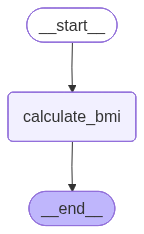

In [3]:
# to view graph structure
from IPython.display import Image
Image(bmi_calculator.get_graph().draw_mermaid_png())

## BMI Calculator with Category

In [4]:
# define state class (includes input and output variables and their types)
class BMIState(TypedDict):
    height_m: float
    weight_kg: float
    bmi: float
    category: str
    
# create graph object and pass state class as parameter 
graph = StateGraph(BMIState)

# define functions
def calculate_bmi(state: BMIState) -> BMIState:
    state['bmi'] = round(state['weight_kg'] / (state['height_m']**2), 2)
    return state

def label_bmi(state: BMIState) -> BMIState:
    bmi = state['bmi']
    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"
    return state
    

# add node and map it to function
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('label_bmi', label_bmi)

# add edges
graph.add_edge(START, 'calculate_bmi') 
graph.add_edge('calculate_bmi', 'label_bmi')
graph.add_edge('label_bmi', END)

# compile graph
bmi_calculator = graph.compile()

# execute the graph
bmi_calculator.invoke({
    "weight_kg": 57,
    "height_m": 1.63
})

{'height_m': 1.63, 'weight_kg': 57, 'bmi': 21.45, 'category': 'Normal'}

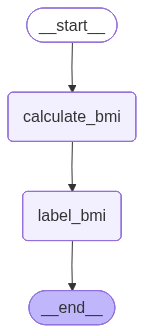

In [5]:
# to view graph structure
from IPython.display import Image
Image(bmi_calculator.get_graph().draw_mermaid_png())

## QA with LLM

In [6]:
from langgraph.graph import StateGraph, END, START
from typing import TypedDict
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv

In [7]:
load_dotenv()

True

In [8]:
# initialize model
model = init_chat_model("google_genai:gemini-2.5-flash")

# create State class
class QAState(TypedDict):
    question: str
    answer: str
    
# create graph
graph = StateGraph(QAState)

# add functions
def llm_qa(state: QAState) -> QAState:
    # extract question
    question = state['question']
    
    # from prompt
    prompt = f'Answer the following question: {question}'
    
    # ask question to LLM
    answer =model.invoke(prompt).content
    
    # update answer in state
    state['answer'] = answer
    
    return state

# add nodes
graph.add_node("llm_qa", llm_qa)

# add edges
graph.add_edge(START, "llm_qa")
graph.add_edge("llm_qa", END)

# compile graph
qa_model = graph.compile()

# ask question
qa_model.invoke({
    "question": "What is the capital of India?"
})

{'question': 'What is the capital of India?',
 'answer': 'The capital of India is **New Delhi**.'}

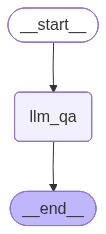

In [9]:
# to view graph structure
from IPython.display import Image
Image(qa_model.get_graph().draw_mermaid_png())

## Blog Generator using Prompt Chaining

In [10]:
from langgraph.graph import StateGraph, END, START
from typing import TypedDict
from langchain.chat_models import init_chat_model

In [11]:
# initialize model
model = init_chat_model("google_genai:gemini-2.5-flash-lite")

# create State class
class BlogState(TypedDict):
    topic: str
    outline: str
    content: str
    
# create graph
graph = StateGraph(BlogState)

# add functions
def create_outline(state: BlogState) -> BlogState:
    topic = state['topic']
    prompt = f'Generate an outline for a blog post on the topic: {topic}'
    outline = model.invoke(prompt).content
    state['outline'] = outline
    return state

def create_blog(state: BlogState) -> BlogState:
    outline = state['outline']
    prompt = f'Generate a blog post on the topic: {state['topic']}, using the given outline: {outline}'
    blog = model.invoke(prompt).content
    state['content'] = blog
    return state
# add nodes
graph.add_node("create_outline", create_outline)
graph.add_node("create_blog", create_blog)

# add edges
graph.add_edge(START, "create_outline")
graph.add_edge("create_outline", "create_blog")
graph.add_edge("create_blog", END)

# compile graph
blog_model = graph.compile()

# ask question
blog_model.invoke({
    "topic": "Valley of Flowers Trek"
})

{'topic': 'Valley of Flowers Trek',
 'outline': '## Valley of Flowers Trek: An Outline for a Blog Post\n\nThis outline aims to provide a comprehensive and engaging blog post about the Valley of Flowers Trek, covering essential information for potential trekkers and inspiring those who dream of visiting.\n\n**I. Catchy Title Options (Choose one or adapt)**\n\n*   Valley of Flowers: A Trekker\'s Paradise Unveiled\n*   Beyond the Blooms: Your Ultimate Guide to the Valley of Flowers Trek\n*   Step into a Fairytale: Conquering the Valley of Flowers Trek\n*   The Valley of Flowers Trek: Where Nature Paints its Masterpiece\n*   Your Dream Trek Awaits: The Enchanting Valley of Flowers\n\n**II. Introduction: Hook the Reader & Set the Scene**\n\n*   **A. Evocative Opening:**\n    *   Paint a vivid picture of the Valley of Flowers – a carpet of vibrant blooms, majestic Himalayas, crisp mountain air.\n    *   Use sensory details (colors, scents, sounds).\n    *   Pose a question to engage the read

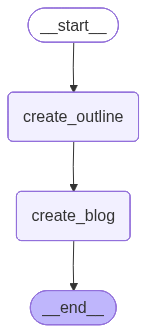

In [12]:
# to view graph structure
from IPython.display import Image
Image(blog_model.get_graph().draw_mermaid_png())